# Customer Churn Prediction

**This notebook follows a structured tabular ML decision framework, emphasizing baseline comparison, ranking evaluation, operating point selection, financial impact simulation, and model interpretability. It is designed both as a case study and as a reusable reference for applied ML projects.**

## Executive Summary

This project develops predictive models to identify telecom customers at risk of churn in order to support targeted retention campaigns.

Two models were evaluated:

- Logistic Regression as an interpretable baseline  
- Gradient Boosting (XGBoost) to capture nonlinear relationships and feature interactions  

Models were evaluated using:

- ROC-AUC for ranking performance  
- Precision–Recall and Average Precision (AP) for imbalanced classification  
- Performance under a fixed contact budget (top 20%)  
- Expected financial value under a simple retention cost model  

### Key Findings

- XGBoost modestly improved ROC-AUC over logistic regression.  
- XGBoost improved Average Precision by ~0.03, indicating cleaner identification of high-risk customers.  
- Under a fixed 20% outreach budget, XGBoost achieved higher precision and increased expected retention value relative to logistic regression.  
- SHAP analysis confirmed intuitive churn drivers and revealed nonlinear effects not captured by the linear model.

### Final Model Decision

Gradient Boosting is selected as the preferred model due to improved high-confidence targeting performance and stronger expected business impact, while maintaining interpretability through SHAP explanations.

---

## Tabular ML Playbook Structure
1. Define the business objective and success criteria  
2. Audit and understand the data  
3. Establish interpretable baseline models (heuristic + logistic regression)  
4. Train higher-capacity model (gradient boosting)  
5. Evaluate ranking performance (ROC-AUC, PR-AUC)  
6. Evaluate operating point under fixed contact budget  
7. Simulate financial impact under explicit cost assumptions  
8. Interpret model behavior (SHAP)  
9. Make and justify deployment decision  

---

## Planned workflow

1. **Load + sanity-check data**  
   - Inspect missing values, column types, target balance

2. **Define target + features**  
   - `y = Churn`  
   - `X = all remaining columns`

3. **Split into train + validation (dev)**  
   - Stratified split  
   - Fixed random seed for reproducibility

4. **Build preprocessing pipeline** *(fit on train only)*  
   - Handle missing values  
   - Encode categorical variables  
   - Scale numeric features if needed

5. **Train a baseline model**  
   - Logistic regression
       - Performance floor
       - Breaks easily -> exposes data / preprocessing bugs
       - Fast to train, low variance
       - Interpretable coefficients (direction + rough magnitude)

6. **Train a stronger model**  
   - Gradient boosting (e.g., XGBoost)
       - Typically best-in-class for tabular data
       - Captures nonlinearity + interactions
       - Requires modest tuning
       - Interpretable post-hoc via feature importance / SHAP, but not as clear as logistic regression

7. **Evaluate on validation set**  
   - ROC-AUC  
   - Precision / recall  
   - Select operating threshold

8. **Interpret results**  
   - Feature importance / SHAP  
   - Error analysis

9. **Write up results**  
   - README: problem → approach → results → next steps  
   - (Optional) final test-set evaluation if added


In [49]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, average_precision_score, precision_recall_curve, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

## EDA

### 1. Load + Basic Shape
- Inspect dataset dimensions using `df.shape`
- Confirm expected number of rows and columns

### 2. Preview Data
- View first few rows with `df.head()`
- Sanity check column names and obvious issues

### 3. Schema Inspection
- Use `df.info()` to examine data types and null counts
- Confirm numeric vs categorical features

### 4. Summary Statistics
- `df.describe()` for numeric features
- `value_counts()` for key categorical variables

### 5. Missingness Analysis
- `df.isna().sum()` to quantify missing data
- Examine patterns of missingness if relevant

### 6. Target Distribution
- Compute overall outcome rate
- Assess class imbalance and baseline difficulty

### 7. Univariate Distributions
- Histograms for numeric features
- Bar charts for categorical features

### 8. Target vs Feature Analysis
- Outcome rate by category
- Numeric features vs target (boxplots or binned comparisons)

### 9. Correlation / Multivariate Scan
- Correlation matrix for numeric variables
- Identify redundant or highly correlated features

### 10. Initial Takeaways
- Strong predictive signals
- Data quality concerns
- Early modeling implications


### Load and inspect data

In [2]:
# Load and inspect data
churn_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convert senior citizen to categorical
churn_df["SeniorCitizen"] = churn_df["SeniorCitizen"].map({0: "No", 1: "Yes"})

display(churn_df.shape)
print()
display(churn_df.info())
print()
display(churn_df.head())
print()
display(churn_df.tail())

(7043, 21)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 

None

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,No,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [3]:
churn_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043,2,No,5901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
for col in churn_df.select_dtypes(include="object"):
    print(f"\n--- {col} ---")
    print(churn_df[col].value_counts(dropna=False))


--- customerID ---
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
4501-VCPFK    1
6075-SLNIL    1
             ..
1452-KIOVK    1
6713-OKOMC    1
7892-POOKP    1
6388-TABGU    1
9763-GRSKD    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes           

### Missingness analysis

In [5]:
# Missingness analysis

churn_df = churn_df.replace(r"^\s*$", np.nan, regex=True)
display(churn_df.isna().sum().sort_values(ascending=False).head(10))


# Is missingness correlated with churn?
missing = churn_df.isna()
missing_by_churn = (
    missing
    .assign(Churn=churn_df["Churn"])
    .groupby("Churn")
    .mean()
    .T
    .sort_values(by="Yes", ascending=False)
)
display(missing_by_churn.head(20))

TotalCharges      11
gender             0
SeniorCitizen      0
Partner            0
customerID         0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
dtype: int64

Churn,No,Yes
customerID,0.000000,0.0
gender,0.000000,0.0
SeniorCitizen,0.000000,0.0
Partner,0.000000,0.0
Dependents,0.000000,0.0
tenure,0.000000,0.0
PhoneService,0.000000,0.0
MultipleLines,0.000000,0.0
InternetService,0.000000,0.0
OnlineSecurity,0.000000,0.0


In [6]:
# Missing total charges is tenure 0, likely new customers, convert missing total charges values to 0
display(churn_df[churn_df["TotalCharges"].isna()][["tenure", "Churn"]])

# TotalCharges should be numeric
churn_df["TotalCharges"] = pd.to_numeric(churn_df["TotalCharges"], errors="coerce")
# Convert missing total charges values to 0
churn_df.loc[churn_df["tenure"] == 0, "TotalCharges"] = 0
display(churn_df["TotalCharges"].dtype)

display(churn_df[churn_df["TotalCharges"].isna()][["tenure", "Churn"]])

,tenure,Churn
488,0,No
753,0,No
936,0,No
1082,0,No
1340,0,No
3331,0,No
3826,0,No
4380,0,No
5218,0,No
6670,0,No


dtype('float64')

,tenure,Churn


### Target distribution

,Count,Proportion
Churn,,
No,5174,0.73463
Yes,1869,0.26537


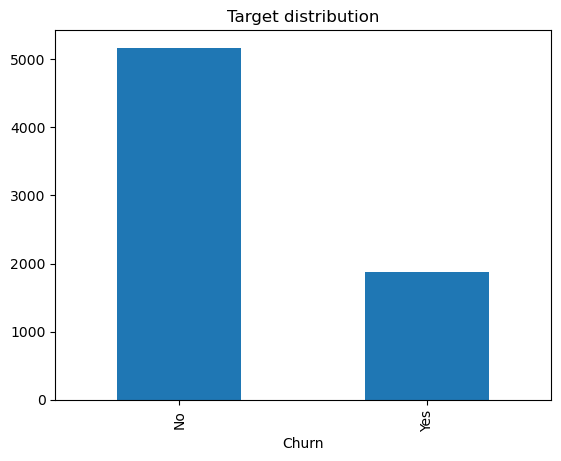

In [7]:
# Target distribution

counts = churn_df["Churn"].value_counts()
proportions = churn_df["Churn"].value_counts(normalize=True)

display(pd.DataFrame({
    "Count": counts,
    "Proportion": proportions
}))

churn_df["Churn"].value_counts().plot(kind="bar", title='Target distribution');

### Univariate Distributions

#### PhoneService is highly imbalanced; likely low marginal predictive power on its own.

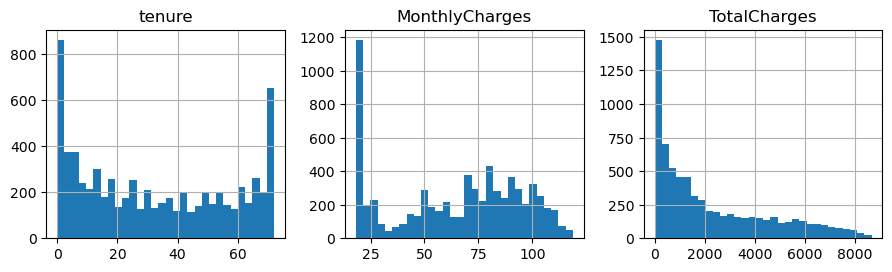

In [8]:
# Univariate Distributions

# Numerical

numeric_cols = churn_df.select_dtypes(include=["int64", "float64"])

numeric_cols.hist(
    bins=30,
    figsize=(15, 10),
    layout=(4, 5)
)

plt.tight_layout()
plt.show()

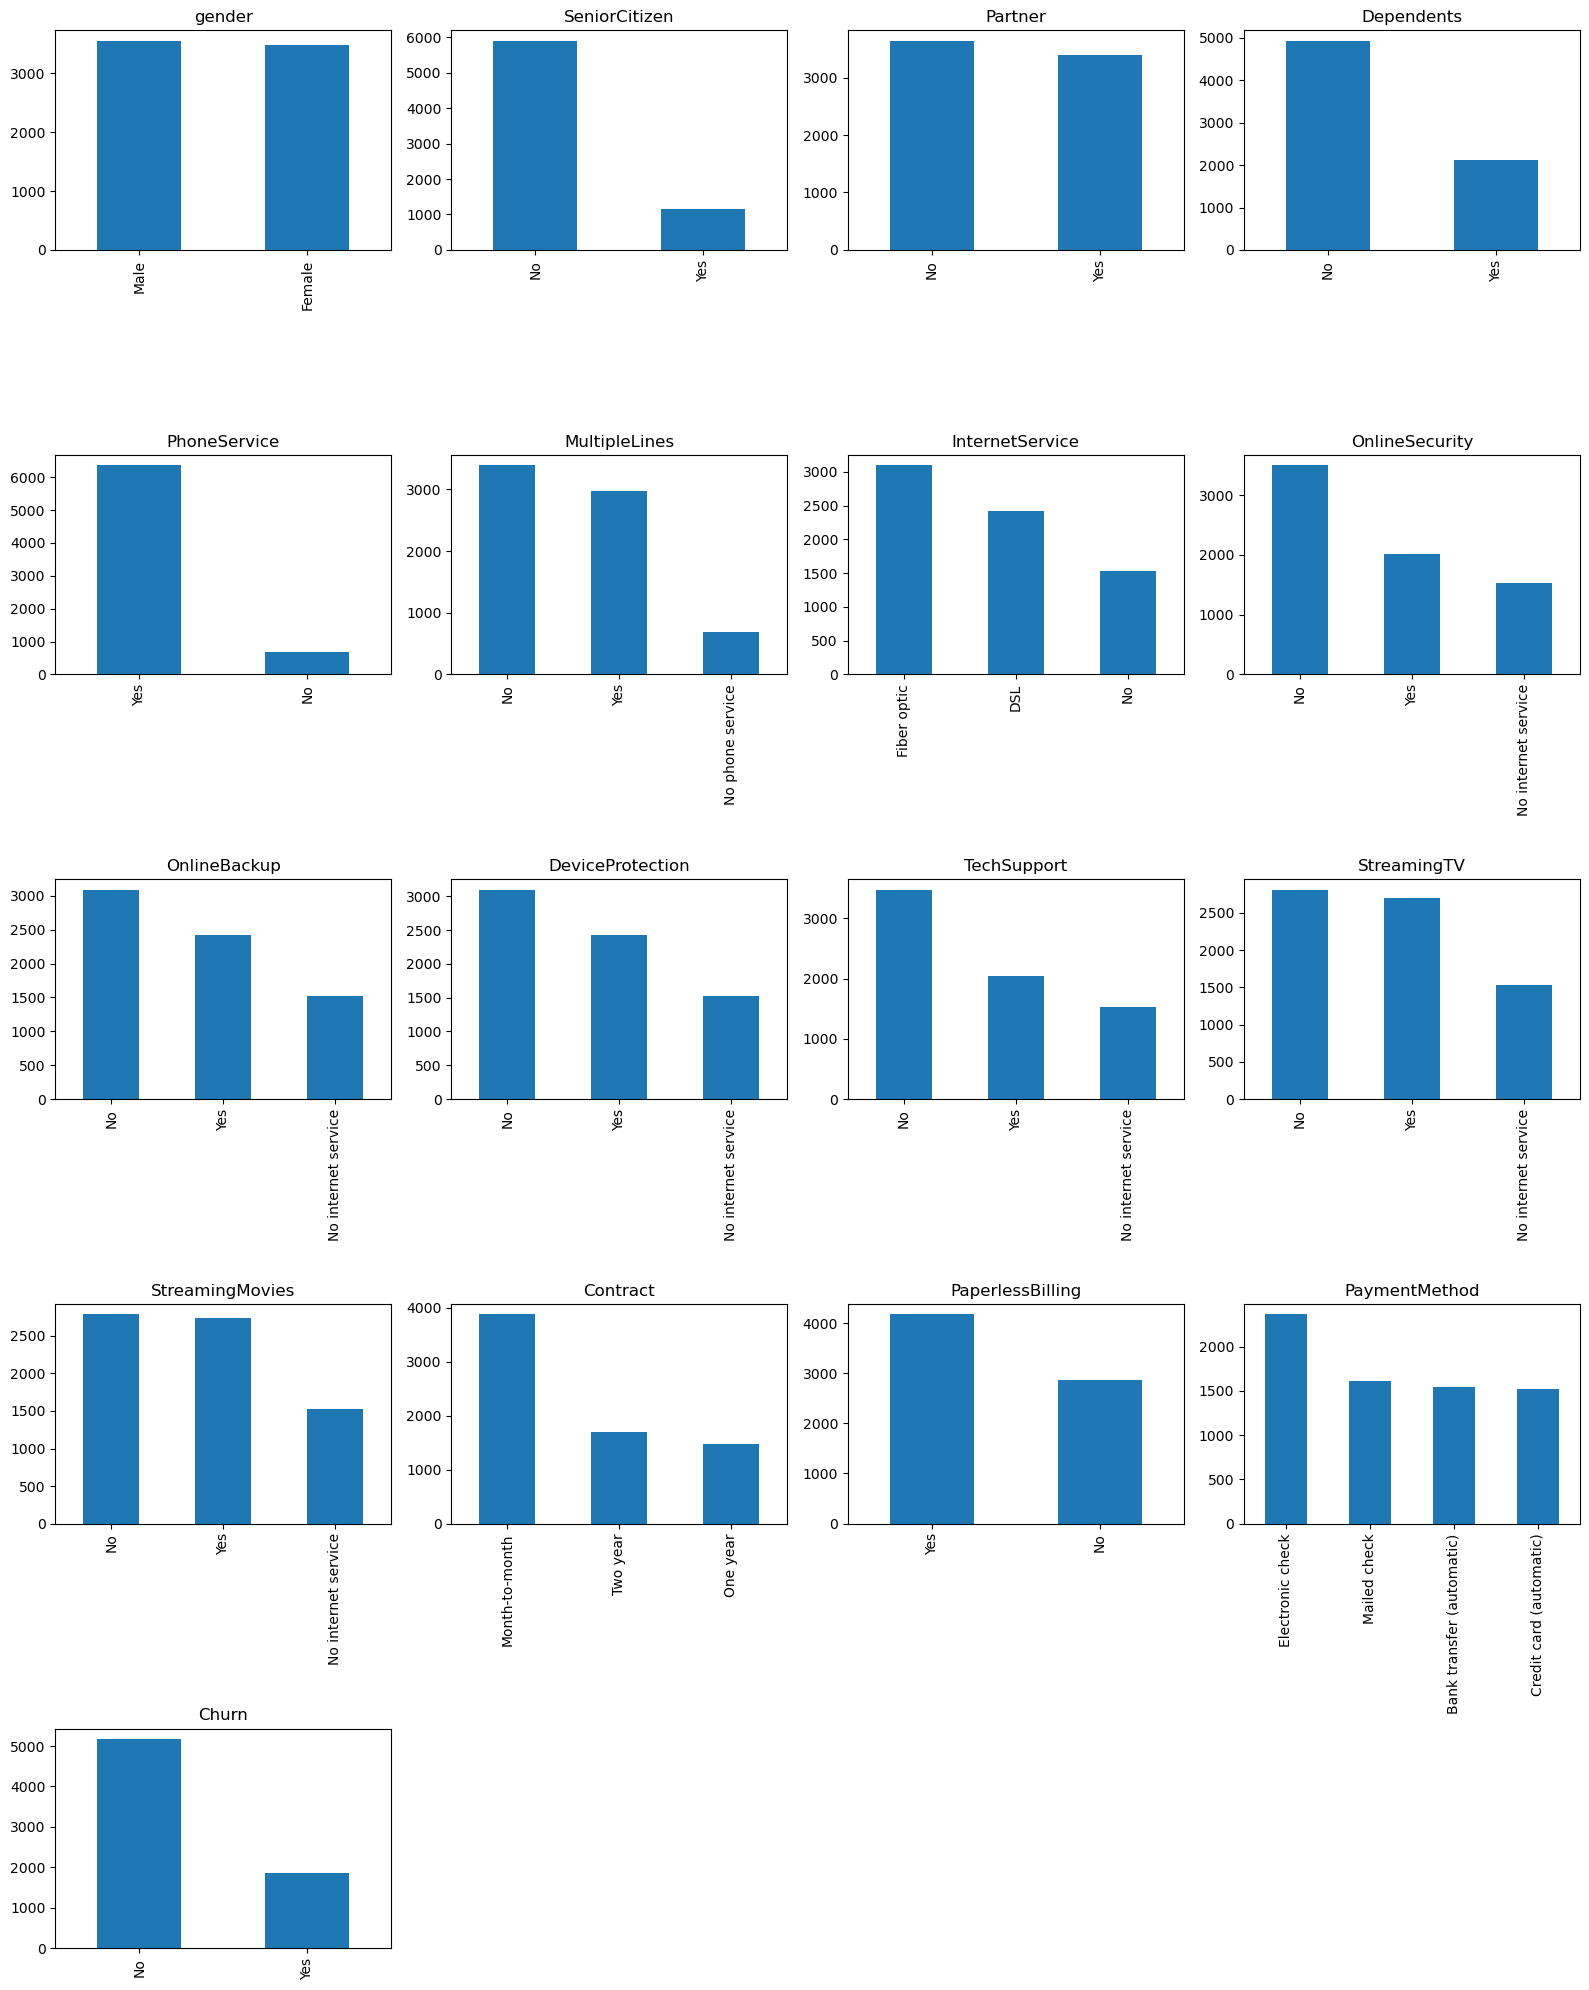

In [9]:
# Categorical

cols = churn_df.select_dtypes(include=["object", "category"]).columns.drop("customerID")
ncols = 4
nrows = -(-len(cols) // ncols)  # ceiling without math

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    churn_df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend().remove() if ax.get_legend() else None

for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

### Target vs Feature Analysis

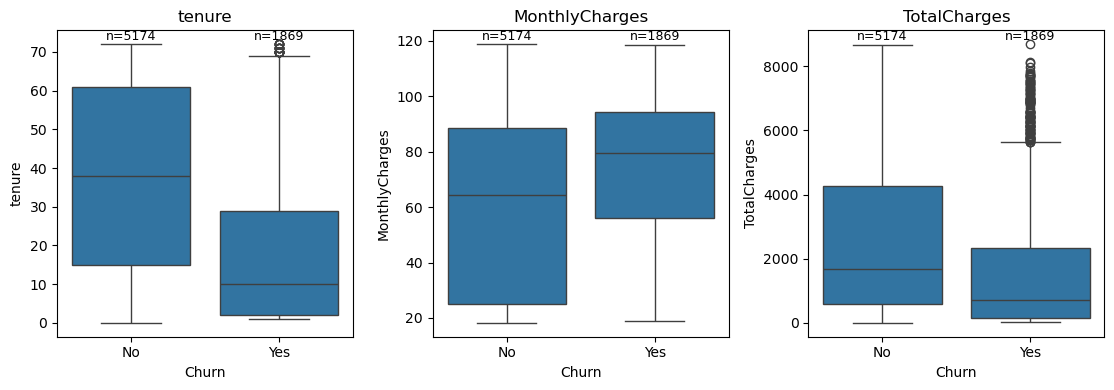

In [10]:
# Numerical

num_cols = churn_df.select_dtypes(include=["int64", "float64"]).columns

ncols = 4
nrows = -(-len(num_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x="Churn", y=col, data=churn_df, ax=ax)
    ax.set_title(col)

    counts = churn_df.groupby("Churn")[col].count()
    for i, (grp, n) in enumerate(counts.items()):
        ax.text(i, ax.get_ylim()[1], f"n={n}", 
                ha="center", va="top", fontsize=9)

for ax in axes[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


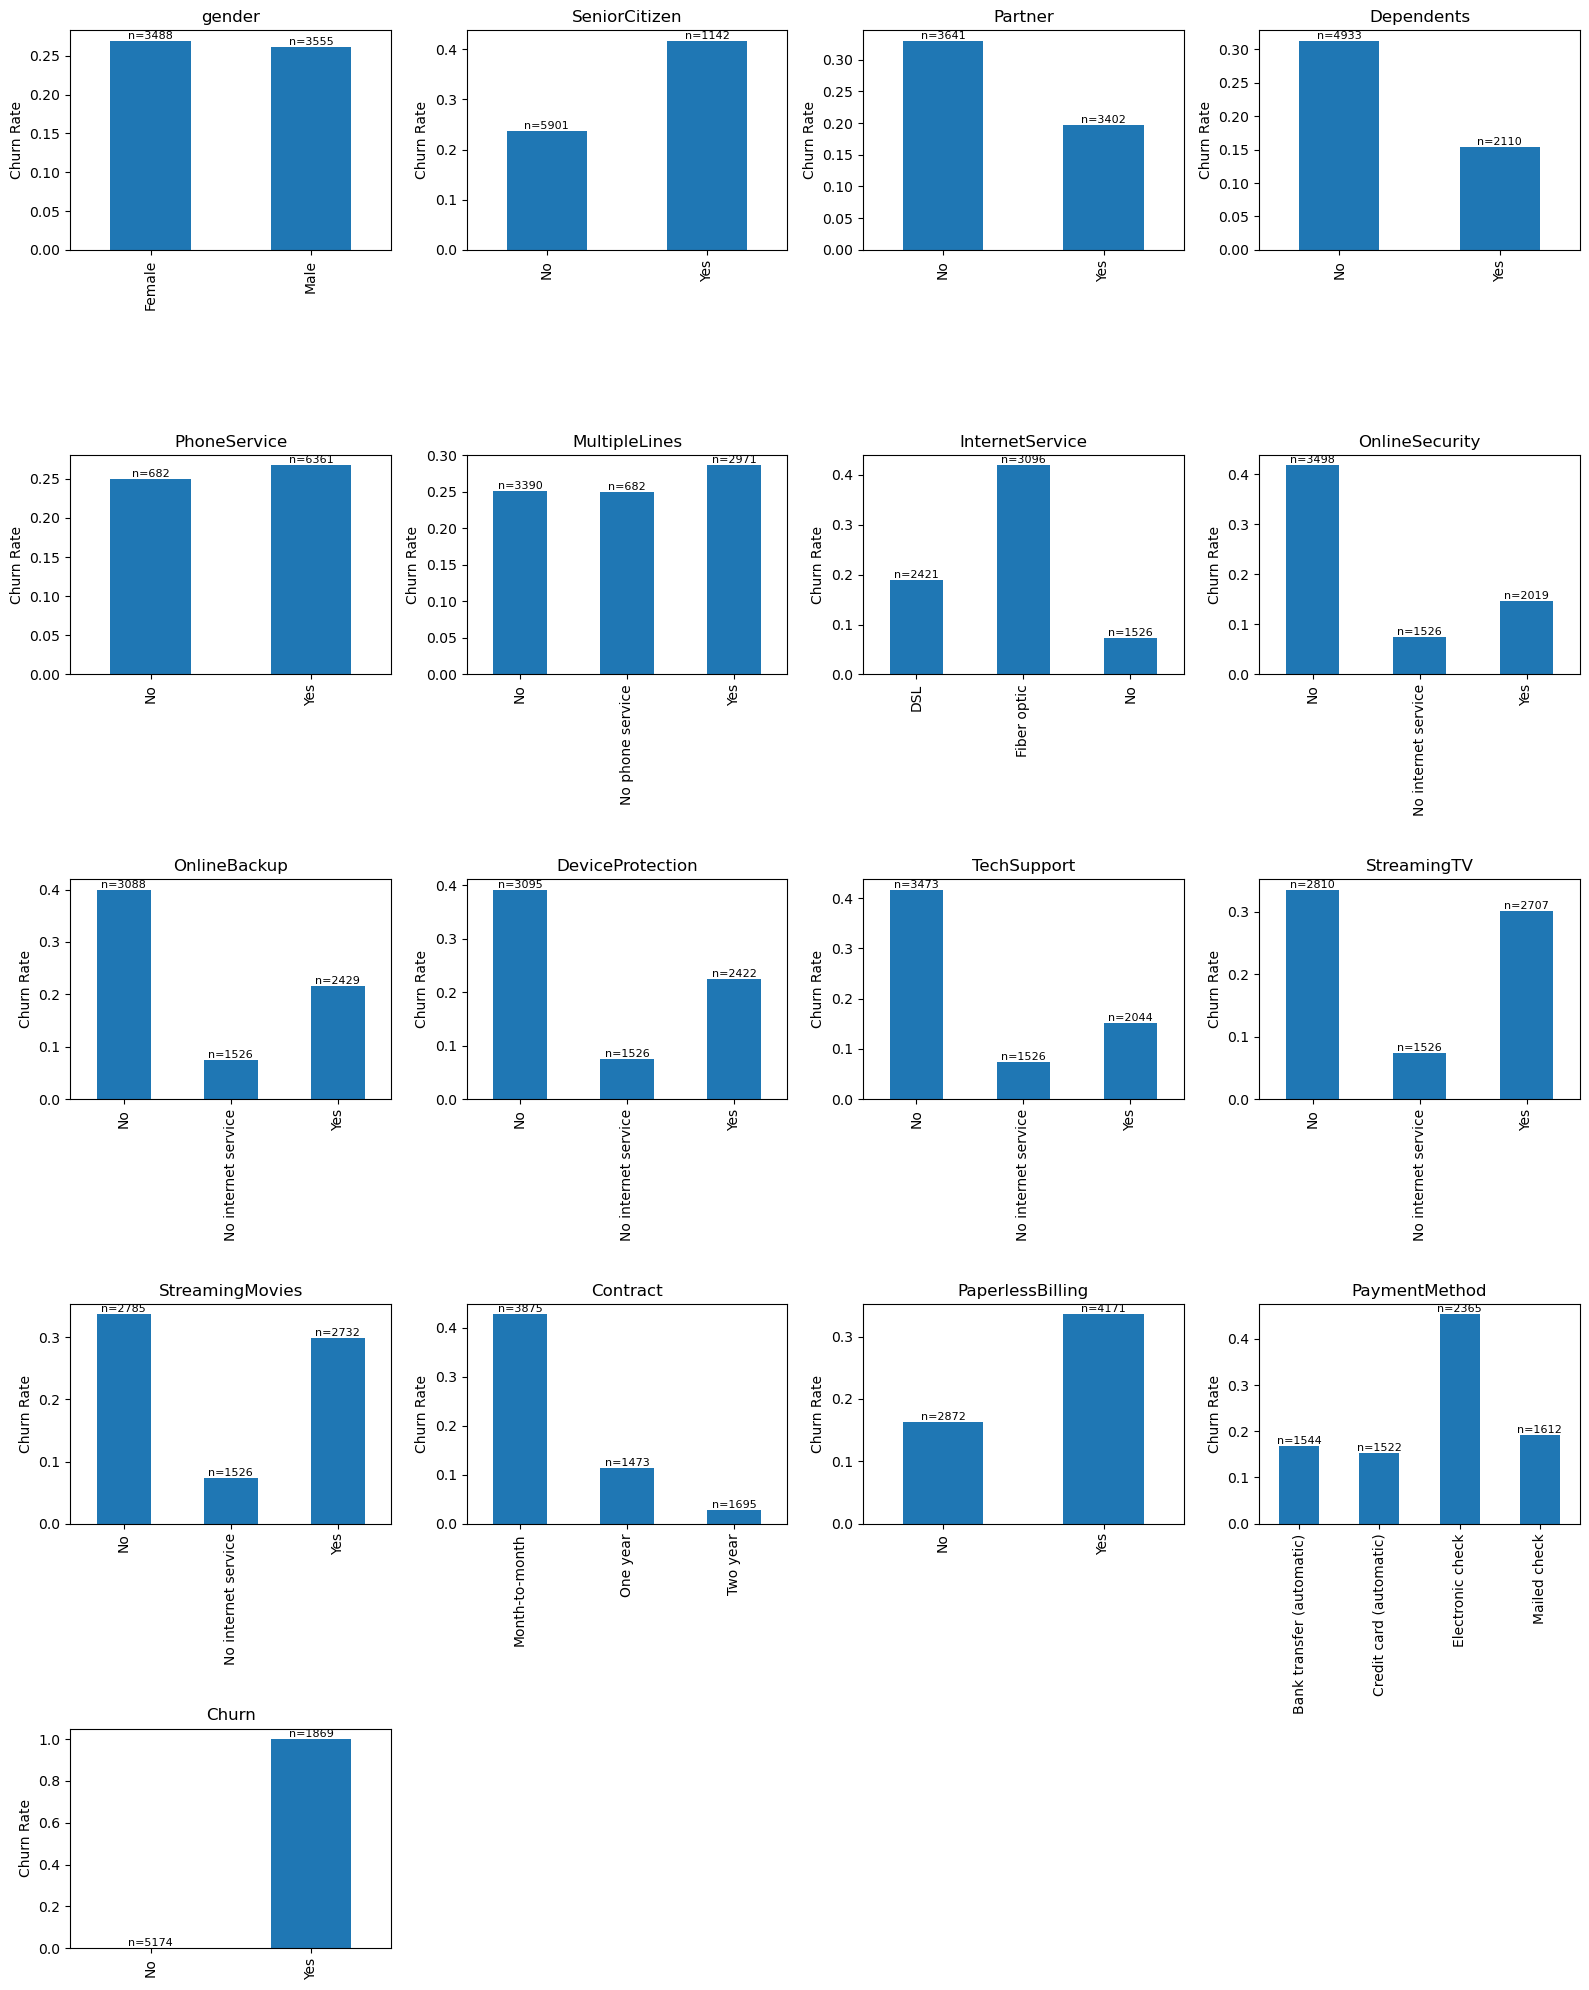

In [11]:
# Categorical

cat_cols = churn_df.select_dtypes(include=["object", "category"]).columns.drop("customerID")

ncols = 4
nrows = -(-len(cat_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(churn_df[col], churn_df["Churn"])
    churn_rate = ct.div(ct.sum(axis=1), axis=0)["Yes"]
    churn_rate.plot(kind="bar", ax=ax)

    for i, val in enumerate(churn_rate):
        ax.text(i, val, f"n={ct.sum(axis=1).iloc[i]}", ha="center", va="bottom", fontsize=8)

    ax.set_title(col)
    ax.set_ylabel("Churn Rate")
    ax.set_xlabel("")

for ax in axes[len(cat_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


### Correlation / Multivariate Scan

#### Tenure and TotalCharges are strongly correlated (~0.83), implying redundancy.

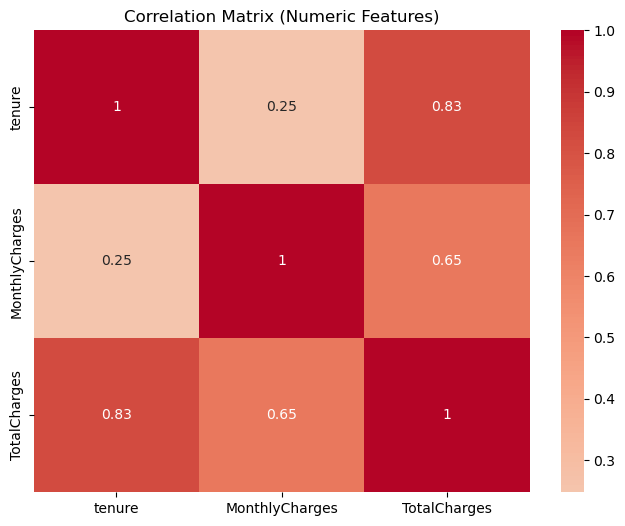

tenure  TotalCharges    0.826178
dtype: float64

In [12]:
num_cols = churn_df.select_dtypes(include=["int64", "float64"]).columns

corr = churn_df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


corr_matrix = churn_df[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

display(high_corr[high_corr > 0.7])

### EDA Takeaways

- Contract type and tenure show the strongest churn separation.
- Add-on services (e.g., OnlineSecurity, TechSupport) appear protective.
- PhoneService is highly imbalanced and likely weak as a standalone predictor.
- Tenure and TotalCharges are strongly correlated (~0.83), implying redundancy.
- Class imbalance is moderate; evaluation should focus on ROC-AUC and threshold tradeoffs.

## Preprocessing

### Define target and features and train / validation split

In [13]:
# Define target and features

TARGET = "Churn"

# Drop ID
X = churn_df.drop(columns=[TARGET, "customerID"])
y = churn_df[TARGET].map({"Yes": 1, "No": 0})

# Standard tabular classification dataset and goal - do stratified split on Y
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Check
display(y_train.mean(), y_val.mean())
X_train.shape, X_val.shape

np.float64(0.2653532126375577)

np.float64(0.2654364797728886)

((5634, 19), (1409, 19))

### Build preprocessing pipeline
- Numeric: impute (median) + scale numeric (needed for logistic regression)
- Categorical: impute (most frequent) + one-hot encode

In [14]:
# Identify column types
numeric_features = X_train.select_dtypes(include=["number"]).columns
categorical_features = X_train.select_dtypes(exclude=["number"]).columns

# Check for mis clasification 
display(X_train[numeric_features].head())
display(X_train[categorical_features].head())

,tenure,MonthlyCharges,TotalCharges
3738,35,49.20,1701.65
3151,15,75.10,1151.55
4860,13,40.55,590.35
3867,26,73.50,1905.70
3810,1,44.55,44.55


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
3738,Male,No,No,No,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check
3151,Male,No,Yes,Yes,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check
4860,Male,No,Yes,Yes,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check
3867,Female,No,Yes,No,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic)
3810,Male,No,Yes,Yes,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check


In [15]:
# Pipeline
# Define preprocessing for each type

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())  # good for logistic regression
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocess

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Baseline model (logistic regression)

In [16]:
# Fit the model

baseline_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

baseline_clf.fit(X_train, y_train)

y_val_proba = baseline_clf.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_val_proba)

roc_auc

0.8420341522643313

In [17]:
average_precision_score(y_val, y_val_proba)

0.6337024099769349

In [18]:
baseline_clf.predict_proba(X_val)

array([[0.95394143, 0.04605857],
       [0.31635212, 0.68364788],
       [0.94127458, 0.05872542],
       ...,
       [0.84572955, 0.15427045],
       [0.99564324, 0.00435676],
       [0.99367929, 0.00632071]], shape=(1409, 2))

### Metrics
- ROC → Is ranking good?
- PR → Is precision-recall tradeoff usable?
- Threshold analysis → What operating point works?
- Calibration → Can we trust the probabilities?

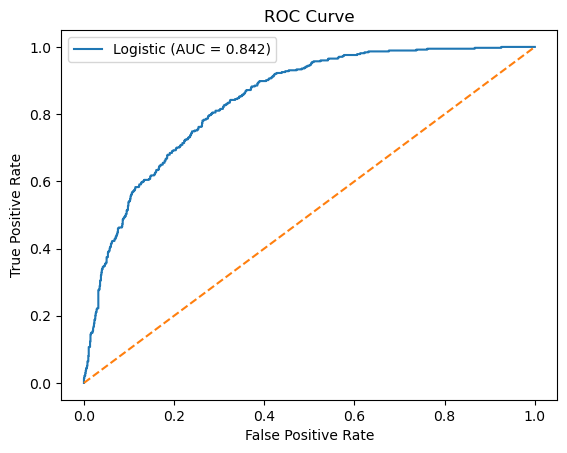

In [19]:
# ROC curve
# Can the model separate churners from non-churners?

fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = roc_auc_score(y_val, y_val_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

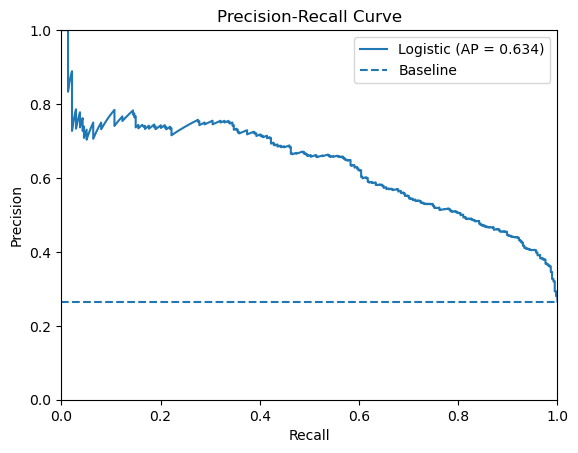

In [44]:
# Precision-Recall
# When we try to capture churners, how clean is the flagged group?
# Base churn rate ~0.27, so a random PR-AUC ~0.27, we're meaningfully above that

precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
pr_auc = average_precision_score(y_val, y_val_proba)

baseline = y_val.mean()

plt.figure()
plt.plot(recall, precision, label=f"Logistic (AP = {pr_auc:.3f})")
plt.hlines(baseline, 0, 1, linestyles="--", label="Baseline")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [21]:
# Check precision and recall at different probability thresholds
# Is precision acceptable at meaningful recall?

results = []

for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_val_proba >= threshold).astype(int)
    
    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred)
    })

pd.DataFrame(results)

,threshold,precision,recall
0,0.3,0.519337,0.754011
1,0.4,0.568182,0.668449
2,0.5,0.657233,0.558824
3,0.6,0.717703,0.401070


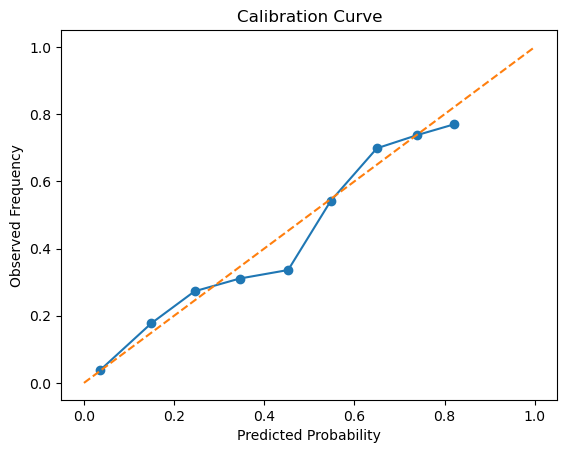

In [22]:
# Calibration curve 
# When the model says 0.7 risk, is that real?

# Take all predicted probabilities.
# Split them into bins (e.g., 10 bins).
# For each bin:
# Compute the average predicted probability in that bin.
# Compute the actual fraction of positives in that bin.

prob_true, prob_pred = calibration_curve(
    y_val, y_val_proba, n_bins=10
)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.show()

In [23]:
# Coefficient inspection

feature_names = baseline_clf.named_steps["preprocess"].get_feature_names_out()
coefs = baseline_clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=False)

# These are log odds coefficients, so convert to odds ratios for something more interpretable
# Odds ratio = 2.0 → doubles odds of churn.
# Odds ratio = 0.5 → halves odds of churn.
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df.head(15)

# Remember:
# One-hot encoding creates many dummy variables.
# Coefficients are relative to the dropped reference category.
# Correlated features (tenure / TotalCharges) can distort magnitudes.

,feature,coefficient,odds_ratio
0,num__tenure,-1.255202,0.285018
39,cat__Contract_Two year,-0.759402,0.467946
17,cat__InternetService_Fiber optic,0.648027,1.911766
16,cat__InternetService_DSL,-0.643642,0.525375
1,num__MonthlyCharges,-0.601168,0.548171
37,cat__Contract_Month-to-month,0.585998,1.796784
2,num__TotalCharges,0.532592,1.703341
40,cat__PaperlessBilling_No,-0.330735,0.718396
26,cat__DeviceProtection_No internet service,-0.292955,0.746056
20,cat__OnlineSecurity_No internet service,-0.292955,0.746056


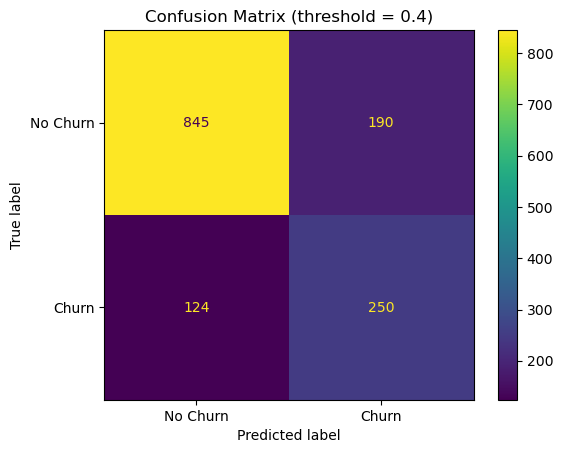

In [29]:
# Confusion matrix at threshold 0.4 to check actual numbers

threshold = 0.4
y_pred = (y_val_proba >= threshold).astype(int)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title(f"Confusion Matrix (threshold = {threshold})")
plt.show()

### Some simple heuristic baseline checks

In [33]:
# Dumb check for absolute worst minimum - Predict All “No”

y_dummy = np.zeros_like(y_val)

precision_score(y_val, y_dummy), recall_score(y_val, y_dummy)

/Users/damon/miniconda3/envs/churn-ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.0, 0.0)

In [27]:
# Simple rule: month to month

y_rule = (X_val["Contract"] == "Month-to-month").astype(int)
precision_score(y_val, y_rule), recall_score(y_val, y_rule)

(0.425614489003881, 0.8796791443850267)

### Cross-validation sanity check

In [34]:
# Cross-validation

cv_auc = cross_val_score(
    baseline_clf,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

# Mean AUC is about the same as the validation for the baseline model
cv_auc.mean(), cv_auc.std()

(np.float64(0.8456836564550466), np.float64(0.013810823205771153))

## Gradient Boosting Model (XGBoost)

In [45]:
# XGboost baseline

xgb_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="auc"
    ))
])

xgb_clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


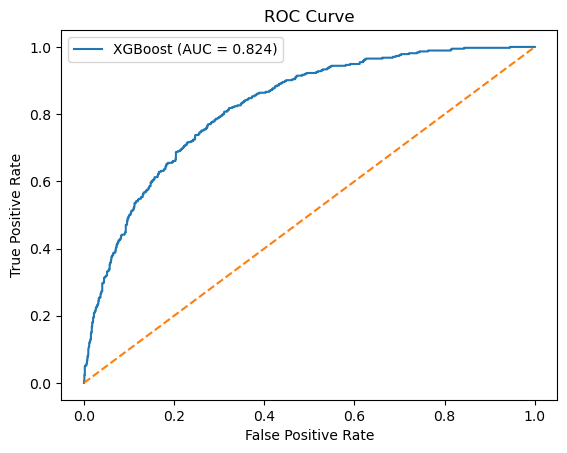

In [46]:
# ROC curve
# Can the model separate churners from non-churners?

y_val_proba_xgb = xgb_clf.predict_proba(X_val)[:, 1]

fpr, tpr, _ = roc_curve(y_val, y_val_proba_xgb)
roc_auc = roc_auc_score(y_val, y_val_proba_xgb)

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

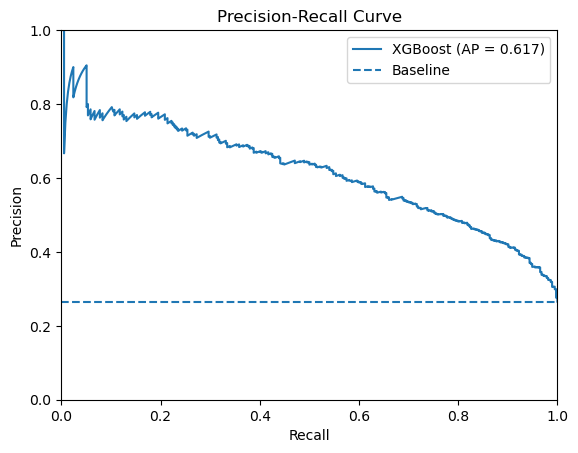

PR-AUC (Average Precision): 0.617


In [47]:
# Precision-Recall curve
# How well does the model identify churners (positive class)?

y_val_proba_xgb = xgb_clf.predict_proba(X_val)[:, 1]

precision, recall, _ = precision_recall_curve(y_val, y_val_proba_xgb)
pr_auc = average_precision_score(y_val, y_val_proba_xgb)

baseline = y_val.mean()

plt.figure()
plt.plot(recall, precision, label=f"XGBoost (AP = {pr_auc:.3f})")
plt.hlines(baseline, 0, 1, linestyles="--", label="Baseline")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print(f"PR-AUC (Average Precision): {pr_auc:.3f}")

### RandomizedSearchCV

In [48]:
xgb_pipe = Pipeline([("preprocess", preprocess),
                     ("model", XGBClassifier(eval_metric="auc", random_state=RANDOM_STATE))])

param_dist = {
 "model__n_estimators":[300,600,1000,1500],
 "model__learning_rate":[0.01,0.03,0.05,0.1],
 "model__max_depth":[2,3,4,5,6],
 "model__min_child_weight":[1,3,5,10],
 "model__subsample":[0.6,0.8,1.0],
 "model__colsample_bytree":[0.6,0.8,1.0],
 "model__reg_lambda":[0.1,1.0,10.0],
}

search = RandomizedSearchCV(xgb_pipe, param_dist, n_iter=30, scoring="roc_auc", cv=5, n_jobs=-1, random_state=RANDOM_STATE)
search.fit(X_train, y_train)
best_xgb = search.best_estimator_

In [52]:
best_idx = search.best_index_

mean_auc = search.cv_results_["mean_test_score"][best_idx]
std_auc  = search.cv_results_["std_test_score"][best_idx]

print(f"Best CV ROC-AUC: {mean_auc:.4f}")
print(f"CV std: {std_auc:.4f}")

print("Best params:")
for k, v in search.best_params_.items():
    print(f"{k}: {v}")

Best CV ROC-AUC: 0.8505
CV std: 0.0144
Best params:
model__subsample: 0.6
model__reg_lambda: 0.1
model__n_estimators: 600
model__min_child_weight: 3
model__max_depth: 3
model__learning_rate: 0.01
model__colsample_bytree: 0.6


In [51]:
cv_results = pd.DataFrame(search.cv_results_)
cv_results.sort_values("mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__reg_lambda,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
25,0.677939,0.043981,0.036203,0.003381,0.6,0.1,600,3,3,0.01,0.6,"{'model__subsample': 0.6, 'model__reg_lambda':...",0.868271,0.860968,0.854131,0.841044,0.828046,0.850492,0.014368,1
11,0.460063,0.021637,0.033060,0.007246,0.8,1.0,600,3,2,0.03,0.6,"{'model__subsample': 0.8, 'model__reg_lambda':...",0.866233,0.860988,0.852451,0.840479,0.826594,0.849349,0.014329,2
19,0.561462,0.008662,0.032068,0.004706,0.8,0.1,300,5,5,0.01,0.8,"{'model__subsample': 0.8, 'model__reg_lambda':...",0.864870,0.860915,0.850094,0.841660,0.827658,0.849039,0.013449,3
27,0.509668,0.008813,0.028513,0.001837,1.0,10.0,600,10,2,0.01,0.8,"{'model__subsample': 1.0, 'model__reg_lambda':...",0.866540,0.859885,0.854846,0.840224,0.822803,0.848860,0.015643,4
5,0.518381,0.031803,0.034922,0.015286,0.8,0.1,300,5,5,0.01,1.0,"{'model__subsample': 0.8, 'model__reg_lambda':...",0.864407,0.859619,0.850338,0.840921,0.827003,0.848458,0.013413,5


### Refit with best parameters and early stopping

In [54]:
# Refit with best parameters and early stopping

best_params = search.best_params_
xgb = XGBClassifier(
    **{k.replace("model__", ""): v for k, v in best_params.items()},
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=RANDOM_STATE
)

xgb.set_params(n_estimators=5000)

xgb.fit(
    Xtr, y_train,
    eval_set=[(Xva, y_val)],
    verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'auc'


In [55]:
# Check validation ROC AUC and AP

y_val_proba_xgb = xgb.predict_proba(Xva)[:, 1]

roc_auc = roc_auc_score(y_val, y_val_proba_xgb)
ap = average_precision_score(y_val, y_val_proba_xgb)

print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation AP: {ap:.4f}")

Validation ROC-AUC: 0.8481
Validation AP: 0.6669


## Model Comparison (logistic vs xgboost)

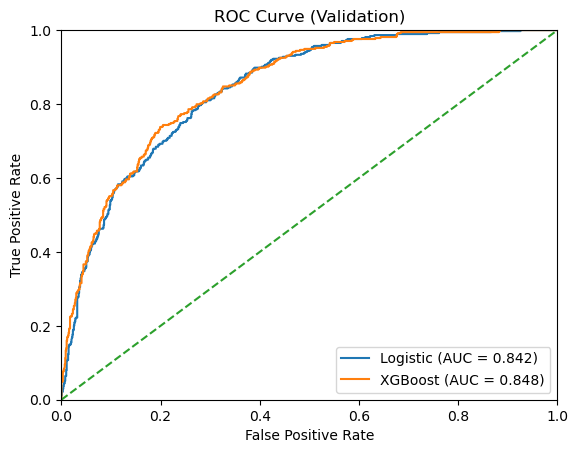

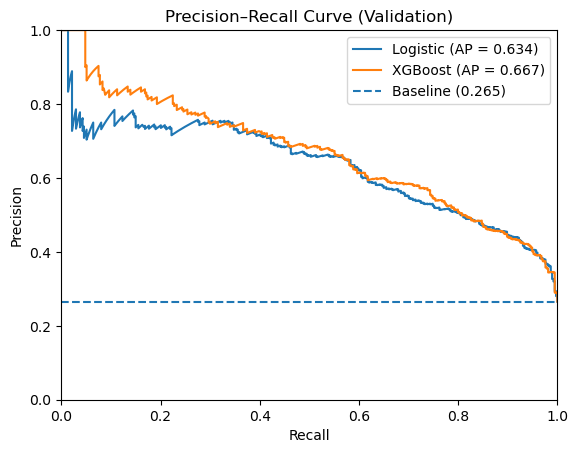

In [56]:
# Compare to logistic regression

# Get probabilities on the SAME validation set
y_val_proba_log = baseline_clf.predict_proba(X_val)[:, 1]
y_val_proba_xgb = xgb.predict_proba(Xva)[:, 1]  # Xva is preprocessed X_val

# 1) Overlay ROC curves
fpr_log, tpr_log, _ = roc_curve(y_val, y_val_proba_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_val_proba_xgb)

auc_log = roc_auc_score(y_val, y_val_proba_log)
auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation)")
plt.legend()
plt.show()

# 2) Overlay PR curves
prec_log, rec_log, _ = precision_recall_curve(y_val, y_val_proba_log)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_val, y_val_proba_xgb)

ap_log = average_precision_score(y_val, y_val_proba_log)
ap_xgb = average_precision_score(y_val, y_val_proba_xgb)

baseline = y_val.mean()

plt.figure()
plt.plot(rec_log, prec_log, label=f"Logistic (AP = {ap_log:.3f})")
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost (AP = {ap_xgb:.3f})")
plt.hlines(baseline, 0, 1, linestyles="--", label=f"Baseline ({baseline:.3f})")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Validation)")
plt.legend()
plt.show()

## Operating Point Selection

In [57]:
# Check precision and recall at different probability thresholds
# Is precision acceptable at meaningful recall?

thresholds = [0.3, 0.4, 0.5, 0.6]
rows = []

for t in thresholds:
    y_pred_log = (y_val_proba_log >= t).astype(int)
    y_pred_xgb = (y_val_proba_xgb >= t).astype(int)

    rows.append({
        "threshold": t,
        "log_precision": precision_score(y_val, y_pred_log),
        "log_recall": recall_score(y_val, y_pred_log),
        "xgb_precision": precision_score(y_val, y_pred_xgb),
        "xgb_recall": recall_score(y_val, y_pred_xgb),
    })

pd.DataFrame(rows)

,threshold,log_precision,log_recall,xgb_precision,xgb_recall
0,0.3,0.519337,0.754011,0.534196,0.772727
1,0.4,0.568182,0.668449,0.594660,0.655080
2,0.5,0.657233,0.558824,0.687050,0.510695
3,0.6,0.717703,0.401070,0.741379,0.344920


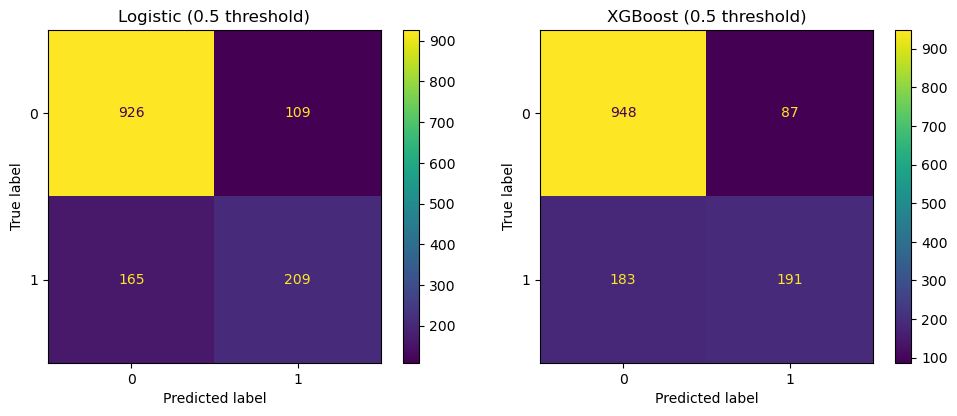

In [58]:
# Confusion matrix

threshold = 0.5

y_pred_log = (y_val_proba_log >= threshold).astype(int)
y_pred_xgb = (y_val_proba_xgb >= threshold).astype(int)

cm_log = confusion_matrix(y_val, y_pred_log)
cm_xgb = confusion_matrix(y_val, y_pred_xgb)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_log).plot(ax=ax[0], values_format="d")
ax[0].set_title("Logistic (0.5 threshold)")

ConfusionMatrixDisplay(cm_xgb).plot(ax=ax[1], values_format="d")
ax[1].set_title("XGBoost (0.5 threshold)")

plt.tight_layout()
plt.show()

### How many churners do we capture if we contact the top 20% most likely to churn based off model prediction?

In [61]:
# How many churners do we capture if we contact the top 20% most likely to churn based off model prediction?

k = int(0.2 * len(y_val))

top_log = np.argsort(-y_val_proba_log)[:k]
top_xgb = np.argsort(-y_val_proba_xgb)[:k]

tp_log = y_val.iloc[top_log].sum()
tp_xgb = y_val.iloc[top_xgb].sum()

precision_log = tp_log / k
precision_xgb = tp_xgb / k

total_churners = y_val.sum()

recall_log = tp_log / total_churners
recall_xgb = tp_xgb / total_churners

results = pd.DataFrame({
    "Model": ["Logistic", "XGBoost"],
    "Customers_Contacted": [k, k],
    "True_Churners_Captured": [tp_log, tp_xgb],
    "Precision": [precision_log, precision_xgb],
    "Recall": [recall_log, recall_xgb],
})

results

,Model,Customers_Contacted,True_Churners_Captured,Precision,Recall
0,Logistic,281,186,0.661922,0.497326
1,XGBoost,281,193,0.686833,0.516043


## SHAP analysis

**Interpretation**
- Top 5 drivers of churn
- Do they align with intuition?
- Any nonlinear patterns logistic couldn’t capture?

PermutationExplainer explainer: 501it [00:13,  9.59it/s]                                                                                                                     


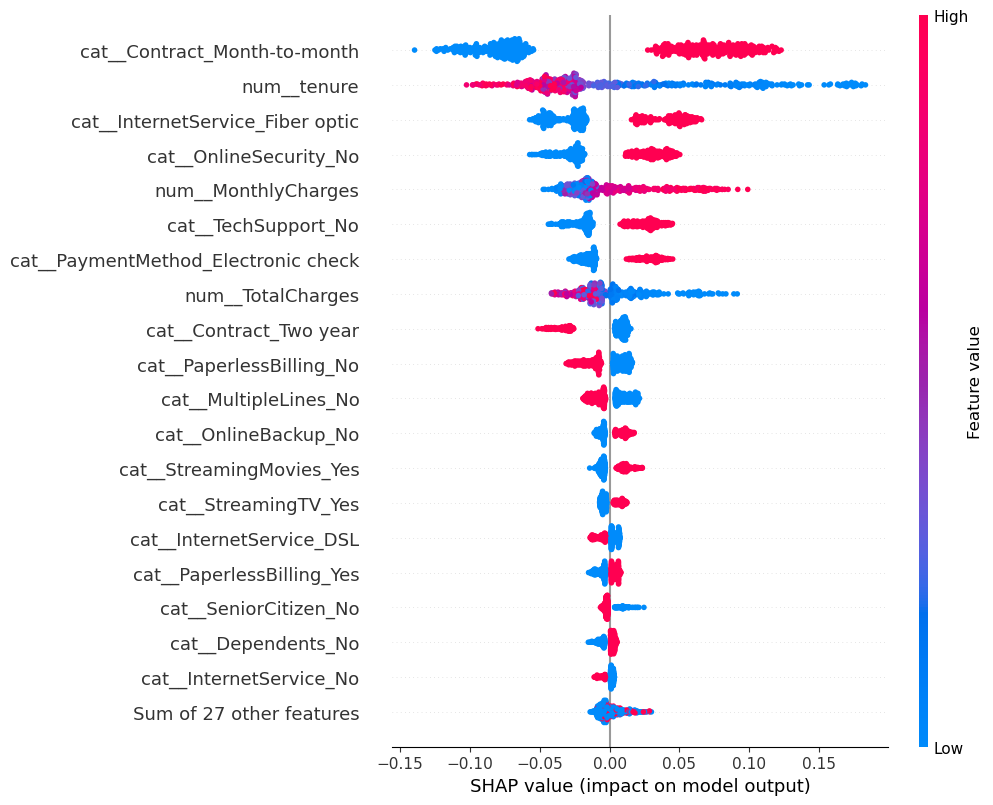

,feature,mean_abs_shap
37,cat__Contract_Month-to-month,0.077496
0,num__tenure,0.055572
17,cat__InternetService_Fiber optic,0.036437
19,cat__OnlineSecurity_No,0.030480
1,num__MonthlyCharges,0.025560
28,cat__TechSupport_No,0.023346
44,cat__PaymentMethod_Electronic check,0.021031
2,num__TotalCharges,0.019067
39,cat__Contract_Two year,0.014897
40,cat__PaperlessBilling_No,0.011410


In [65]:
# SHAP analysis

feature_names = preprocess.get_feature_names_out()

# sample for speed (SHAP can be slow on full validation)
idx = np.random.RandomState(0).choice(Xva.shape[0], size=min(500, Xva.shape[0]), replace=False)
Xva_s = Xva[idx]

# explain probability of churn
f = lambda X: xgb.predict_proba(X)[:, 1]

explainer = shap.Explainer(f, Xva_s, feature_names=feature_names)
shap_values = explainer(Xva_s)

shap.plots.beeswarm(shap_values, max_display=20)

# Top feature importance numerically:
mean_abs = np.abs(shap_values.values).mean(axis=0)
feat = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
feat.head(15)

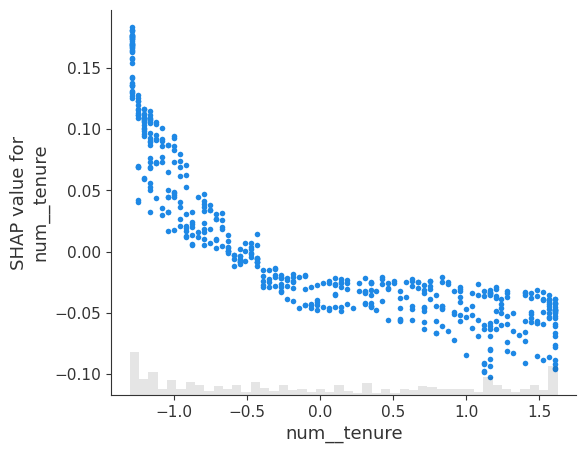

In [73]:
# Confirm non-linearity (curves)

shap.plots.scatter(shap_values[:, 'num__tenure'])

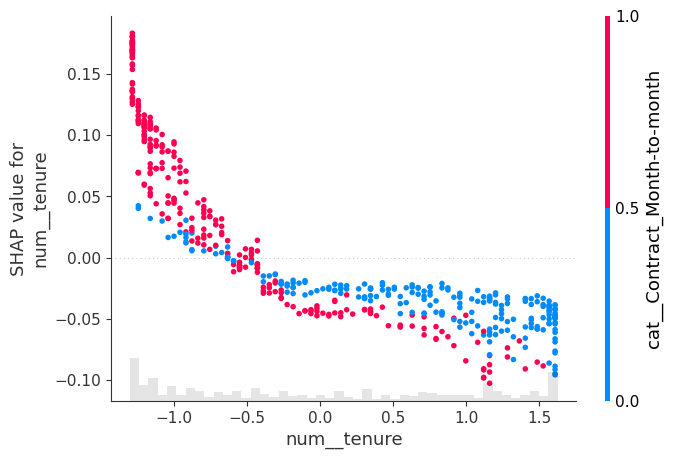

In [72]:
# Check for interaction: tenure and contract

shap.plots.scatter(
    shap_values[:, tenure_feat],
    color=shap_values[:, "cat__Contract_Month-to-month"]
)

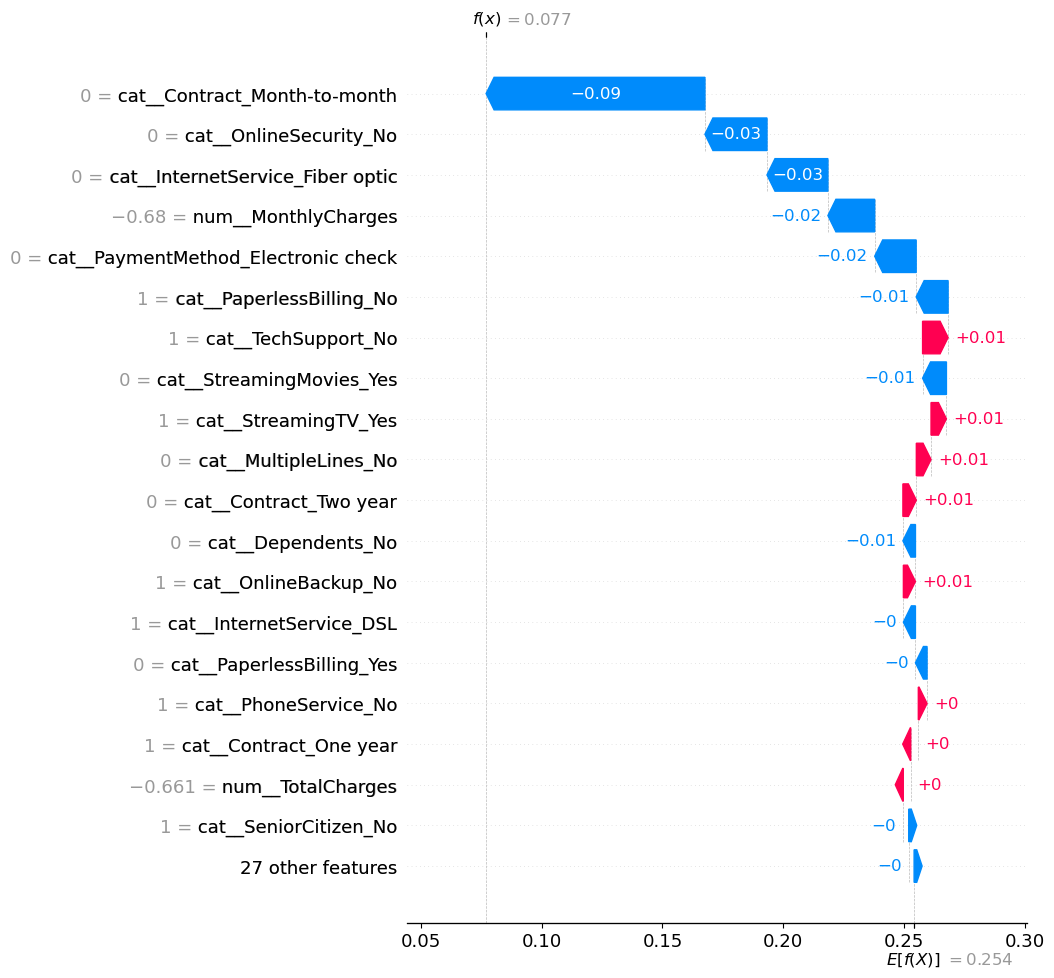

In [66]:
# Individual explanation (one customer):

shap.plots.waterfall(shap_values[0], max_display=20)

#### Compare interpretability

Briefly contrast:
- Logistic coefficients
- XGBoost SHAP patterns

If conclusions are similar → logistic is sufficient.
If XGB reveals new structure → that’s justification.

## Business simulation impact

**Assumptions:**
- Contact cost = $50

- If churner is contacted and retained -> $500 value saved
- No benefit if non-churner contacted

In [79]:
# Business simulation impact

contact_cost = 50
retention_value = 500

# Number of customers captured if we contact the top 20% most likely to churn based off model prediction
k = int(0.2 * len(y_val))

top_log = np.argsort(-y_val_proba_log)[:k]
top_xgb = np.argsort(-y_val_proba_xgb)[:k]

tp_log = y_val.iloc[top_log].sum()
tp_xgb = y_val.iloc[top_xgb].sum()

fp_log = k - tp_log
fp_xgb = k - tp_xgb

profit_log = tp_log * retention_value - k * contact_cost
profit_xgb = tp_xgb * retention_value - k * contact_cost

print("Customers contacted:", k)
print("True churners captured (Logistic):", tp_log)
print("True churners captured (XGB):", tp_xgb)
print("Logistic profit:", profit_log)
print("XGBoost profit:", profit_xgb)
print("Difference:", profit_xgb - profit_log)

Customers contacted: 281
True churners captured (Logistic): 186
True churners captured (XGB): 193
Logistic profit: 78950
XGBoost profit: 82450
Difference: 3500


In [80]:
# Probably not every customer contacted will accept offer, add a guessed success rate

retention_rate = 0.3  # 30% of churners accept offer

profit_log = tp_log * retention_rate * retention_value - k * contact_cost
profit_xgb = tp_xgb * retention_rate * retention_value - k * contact_cost

print("Customers contacted:", k)
print("True churners captured (Logistic):", tp_log)
print("True churners captured (XGB):", tp_xgb)
print("Logistic profit:", profit_log)
print("XGBoost profit:", profit_xgb)
print("Difference:", profit_xgb - profit_log)

Customers contacted: 281
True churners captured (Logistic): 186
True churners captured (XGB): 193
Logistic profit: 13850.0
XGBoost profit: 14900.0
Difference: 1050.0


## Final Model Decision

- Logistic regression and XGBoost achieved similar ROC-AUC (~0.84–0.85).  
- XGBoost improved Average Precision by ~0.03, indicating better ranking of high-risk customers.  
- Under a fixed 20% contact budget, XGBoost achieved higher precision and captured more true churners.  
- Financial simulation showed higher expected retention value with XGBoost under the assumed cost model.  
- SHAP analysis confirmed intuitive churn drivers and revealed modest nonlinear effects not captured by the linear model.  

**Decision:** Deploy the XGBoost model for retention targeting.